In [1]:
import torch.nn.functional as F
from torch import nn
import torch, math


class CoordFourierPE(nn.Module):

    def __init__(self, hidden_dim, num_freq=8):
        super().__init__()

        freq = 2.0**torch.arange(num_freq)
        self.register_buffer("freq", freq)

        self.proj = nn.Sequential(
            nn.Linear(2+num_freq*4, hidden_dim, bias=False),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
    def forward(self, data, typeData):
        device = data.device
        if typeData == "mat":
            _b, _, _h, _w = data.shape
            yy, xx = torch.meshgrid(torch.linspace(0, 1, _h+1)[:-1], torch.linspace(0, 1, _w+1)[:-1], indexing="ij")
            data = torch.stack([xx, yy], dim=-1)
            data = data.reshape(1, _h*_w, 2).repeat(_b,1,1).to(device)

        x = data[..., 0:1]
        y = data[..., 1:2]
        freq = self.freq.to(device)
        x_freq = 2 * math.pi * x * freq
        y_freq = 2 * math.pi * y * freq

        fourier = torch.cat([torch.sin(x_freq), torch.cos(x_freq), torch.sin(y_freq), torch.cos(y_freq)], dim=-1)
        feature = torch.cat([data, fourier], dim=-1)
        return self.proj(feature)

class vertexRelativisticEncoding(nn.Module):
    def __init__(self, chan):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(6, chan, bias=False),
            nn.LayerNorm(chan),
            nn.GELU(),
        )
    def forward(self, x):
        x = self.proj(x)
        return x

class PolygonEmbedding(nn.Module):
    def __init__(self, chan):
        super().__init__()
        self.vertexRelativisticEncoder = vertexRelativisticEncoding(chan)
        encoderLayer = nn.TransformerEncoderLayer(
            d_model=chan,
            nhead=4,
            dim_feedforward=chan * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoderLayer,
            num_layers=4
        )
        self.norm = nn.LayerNorm(chan)
    def forward(self, xy, polyPad):
        x = self.vertexRelativisticEncoder(xy)
        x = self.transformer(x, src_key_padding_mask=~polyPad)
        x = self.norm(x)
        return x

class PolyTrans(nn.Module):
    def __init__(self, chanIn, chanOut, numHead, chanPoly):
        super().__init__()
        self.chanMid = chanOut // numHead * numHead
        self.chanEach = self.chanMid // numHead
        self.numHead = numHead
        self.embedPolyQ = nn.Sequential(
            nn.Linear(chanIn+chanPoly, self.chanMid, bias=False),
            nn.LayerNorm(self.chanMid)
        )
        self.embedPolyK = nn.Sequential(
            nn.Linear(chanPoly*2, self.chanMid, bias=False),
            nn.LayerNorm(self.chanMid)
        )
        self.embedPolyV = nn.Sequential(
            nn.Linear(chanPoly*2, self.chanMid, bias=False),
            nn.LayerNorm(self.chanMid)
        )
        self.mlpAttPoly = nn.Sequential(
            nn.Linear(self.chanMid, chanOut, bias=False),
            nn.Dropout(0.1)
        )
        self.FFNExpandPoly = nn.Sequential(
            nn.LayerNorm(chanOut),
            nn.Linear(chanOut, chanOut*4, bias=False),
            nn.Dropout(0.1)
        )
        self.FFNConv2DPoly = nn.Sequential(
            nn.Conv2d(chanOut*4, chanOut*4, kernel_size=3, stride=1, padding=1, groups=chanOut*4, bias=False),
            nn.GELU(),
            nn.Conv2d(chanOut*4, chanOut, kernel_size=1, stride=1, padding=0, bias=False)
        )
        self.normFinPoly = nn.LayerNorm(chanOut)
    def forward(self, pack):
        x, polyEmbed, polyPad, gridPE, polyPE = pack
        b, c, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)
        
        q = self.embedPolyQ(torch.concat([x, gridPE], -1)).reshape(b, -1, self.numHead, self.chanEach).transpose(1, 2)
        k = self.embedPolyK(torch.concat([polyEmbed, polyPE], -1)).reshape(b, -1, self.numHead, self.chanEach).transpose(1, 2)
        v = self.embedPolyV(torch.concat([polyEmbed, polyPE], -1)).reshape(b, -1, self.numHead, self.chanEach).transpose(1, 2)
        attPoly = F.scaled_dot_product_attention(query=q, key=k, value=v, dropout_p=0.1 if self.training else 0.0, is_causal=False, attn_mask=polyPad[:,None,None,:])
        x = x + self.mlpAttPoly(attPoly.transpose(1, 2).reshape(b, -1, self.chanMid))
        xFFN = self.FFNExpandPoly(x)
        xFFN = self.FFNConv2DPoly(xFFN.transpose(1, 2).reshape(b, -1, h, w))
        x = x + xFFN.flatten(2).transpose(1, 2)

        x = self.normFinPoly(x)
        x = x.transpose(1, 2).reshape(b, -1, h, w).contiguous()
        return x, polyEmbed, polyPad, gridPE, polyPE

class poly2mat(nn.Module):
    def __init__(self, chanIn=1, chanPoly=64, chanOut=1, scaleList=[1.0, 0.5, 0.25, 0.125], chanMidList=[32, 64, 128, 256], repeatAttList=[3, 3, 3, 3]):
        super().__init__()
        self.scaleList = scaleList
        self.embedPoly = PolygonEmbedding(chanPoly)
        self.coorinateEmbed = CoordFourierPE(chanPoly)
        self.conv2dEncode1 = nn.Sequential(
            nn.Conv2d(chanIn, chanMidList[0], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[0]),
            nn.BatchNorm2d(chanMidList[0]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dEncode2 = nn.Sequential(
            nn.Conv2d(chanMidList[0], chanMidList[1], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[1]),
            nn.BatchNorm2d(chanMidList[1]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dEncode3 = nn.Sequential(
            nn.Conv2d(chanMidList[1], chanMidList[2], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[2]),
            nn.BatchNorm2d(chanMidList[2]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dEncode4 = nn.Sequential(
            nn.Conv2d(chanMidList[2], chanMidList[3], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[3]),
            nn.BatchNorm2d(chanMidList[3]),
            nn.LeakyReLU(0.01),
        )
        self.trans1 = nn.Sequential(*[PolyTrans(chanMidList[3], chanMidList[3], 1, chanPoly) for i in range(repeatAttList[0])])
        self.trans2 = nn.Sequential(*[PolyTrans(chanMidList[2], chanMidList[2], 2, chanPoly) for i in range(repeatAttList[1])])
        self.trans3 = nn.Sequential(*[PolyTrans(chanMidList[1], chanMidList[1], 3, chanPoly) for i in range(repeatAttList[2])])
        self.trans4 = nn.Sequential(*[PolyTrans(chanMidList[0], chanMidList[0], 4, chanPoly) for i in range(repeatAttList[3])])
        self.conv2dDecode1 = nn.Sequential(
            nn.Conv2d(chanMidList[3]*2, chanMidList[2], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[2]),
            nn.BatchNorm2d(chanMidList[2]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dDecode2 = nn.Sequential(
            nn.Conv2d(chanMidList[2]*2, chanMidList[1], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[1]),
            nn.BatchNorm2d(chanMidList[1]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dDecode3 = nn.Sequential(
            nn.Conv2d(chanMidList[1]*2, chanMidList[0], 3, 1, 1, bias=False),
            # nn.InstanceNorm2d(chanMidList[0]),
            nn.BatchNorm2d(chanMidList[0]),
            nn.LeakyReLU(0.01),
        )
        self.conv2dDecode4 = nn.Sequential(
            nn.Conv2d(chanMidList[0]*2, chanOut, 3, 1, 1),
            nn.Sigmoid()
        )
    def forward(self, x, poly=None, polyPad=None):
        if poly is not None:
            polyPE = self.coorinateEmbed(poly[:,:,:2], "poly")
            polyEmbed = self.embedPoly(poly, polyPad)
        b, c, h, w = x.shape
        xList = []
        idx = 0
        x = F.interpolate(x, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False)
        x = self.conv2dEncode1(x)
        xList.append(x)
        idx = 1
        x = F.interpolate(x, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False)
        x = self.conv2dEncode2(x)
        xList.append(x)
        idx = 2
        x = F.interpolate(x, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False)
        x = self.conv2dEncode3(x)
        xList.append(x)
        idx = 3
        x = F.interpolate(x, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False)
        x = self.conv2dEncode4(x)
        xList.append(x)

        feature = x
        idx = 3
        if poly is not None:
            gridPE = self.coorinateEmbed(feature, "mat")
            feature, polyEmbed, polyPad, gridPE, polyPE = self.trans1([feature, polyEmbed, polyPad, gridPE, polyPE])
        feature = torch.concat([F.interpolate(feature, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False), xList[idx]], 1)
        feature = self.conv2dDecode1(feature)

        idx = 2
        if poly is not None:
            gridPE = self.coorinateEmbed(feature, "mat")
            feature, polyEmbed, polyPad, gridPE, polyPE = self.trans2([feature, polyEmbed, polyPad, gridPE, polyPE])
        feature = torch.concat([F.interpolate(feature, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False), xList[idx]], 1)
        feature = self.conv2dDecode2(feature)

        idx = 1
        if poly is not None:
            gridPE = self.coorinateEmbed(feature, "mat")
            feature, polyEmbed, polyPad, gridPE, polyPE = self.trans3([feature, polyEmbed, polyPad, gridPE, polyPE])
        feature = torch.concat([F.interpolate(feature, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False), xList[idx]], 1)
        feature = self.conv2dDecode3(feature)

        idx = 0
        if poly is not None:
            gridPE = self.coorinateEmbed(feature, "mat")
            feature, polyEmbed, polyPad, gridPE, polyPE = self.trans4([feature, polyEmbed, polyPad, gridPE, polyPE])
        feature = torch.concat([F.interpolate(feature, size=(int(h*self.scaleList[idx]), int(w*self.scaleList[idx])), mode="bilinear", align_corners=False), xList[idx]], 1)
        feature = self.conv2dDecode4(feature)
        x = feature
        return x

In [2]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np
import pickle, cv2

def EulerTransformation(polygon, angle, center=(0, 0)):
    angle = np.radians(angle)
    cos = np.cos(angle)
    sin = np.sin(angle)
    cx, cy = center
    polygonRot = []
    for x, y in polygon:
        tx, ty = x - cx, y - cy
        rx = tx * cos - ty * sin
        ry = tx * sin + ty * cos
        x = rx + cx
        y = ry + cy
        polygonRot.append((x, y))
    return np.array(polygonRot)

def MakeCoordinatesNMat(rangeAngle=[-45, 45], rangeNum=[1, 4], sizeWH=[128, 64], wRange=[8, 128], hRange=[8, 128], blur=5, scale=5, dilate=3):
    xRect = np.random.uniform(sizeWH[0])
    yRect = np.random.uniform(sizeWH[1])
    wRect = np.random.uniform(*wRange)
    hRect = np.random.uniform(*hRange)
    xSta = xRect-wRect/2
    ySta = yRect-hRect/2
    xEnd = xRect+wRect/2
    yEnd = yRect+hRect/2
    label = np.zeros([int(sizeWH[1]*scale*1.5), int(sizeWH[0]*scale*1.5)], dtype=np.uint8)
    num = np.random.randint(rangeNum[0]-1, rangeNum[1])
    coordinates = [np.array([[xSta, ySta], [xSta, yEnd], [xEnd, yEnd], [xEnd, ySta]])]
    for i in range(num):
        xStaNega, xEndNega = np.sort(np.random.uniform(xSta-wRect/2, xEnd+wRect/2, 2))
        yStaNega, yEndNega = np.sort(np.random.uniform(ySta-hRect/2, yEnd+hRect/2, 2))
        coordinates.append(np.array([[xStaNega, yStaNega], [xStaNega, yEndNega], [xEndNega, yEndNega], [xEndNega, yStaNega]]))
    cv2.fillPoly(label, [(coordinate*scale+np.array([sizeWH[0], sizeWH[1]])*scale*0.2).astype(int) for coordinate in coordinates], color=255)
    contours, _ = cv2.findContours(label, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    _h, _w = label.shape
    angle = np.random.uniform(*rangeAngle)
    contours = [EulerTransformation(contour[:,0], -angle, (_w/2, _h/2)).astype(int) for contour in contours]
    label = cv2.fillPoly(np.zeros([int(sizeWH[1]*scale*1.5), int(sizeWH[0]*scale*1.5)], dtype=np.uint8), contours, 255)[int(sizeWH[1]*scale*0.25):-int(sizeWH[1]*scale*0.25),int(sizeWH[0]*scale*0.25):-int(sizeWH[0]*scale*0.25)]
    contours = [contour/scale-np.array([sizeWH[0], sizeWH[1]])*0.25 for contour in contours]
    data = label
    if dilate > 0:
        label = cv2.dilate(label, np.ones([dilate*scale, dilate*scale]))
    if blur > 0:
        label = cv2.blur(label, ksize=(blur*scale, blur*scale))
    data = cv2.resize(data, dsize=(sizeWH[0], sizeWH[1]), interpolation=cv2.INTER_LINEAR)
    label = cv2.resize(label, dsize=(sizeWH[0], sizeWH[1]), interpolation=cv2.INTER_LINEAR)
    return data, label, contours

def collate_fn_padd(batch):
    dataList = []
    labelList = []
    _coordinatesList = []
    for pack in batch:
        data, label, coordinates = pack
        dataList.append(data)
        labelList.append(label)
        _coordinatesList.append(coordinates)
    maxVertex = max([coordinates.shape[0] for coordinates in _coordinatesList])
    coordinatesList = torch.zeros(len(dataList), maxVertex, 6)
    coordinatePadsList = torch.zeros(len(dataList), maxVertex).to(torch.bool)
    for idx, coordinates in enumerate(_coordinatesList):
        coordinatesList[idx,:len(coordinates)] = coordinates
        coordinatePadsList[idx,:len(coordinates)] = True
    return torch.stack(dataList), torch.stack(labelList), coordinatesList, coordinatePadsList

class PolyDataset(Dataset):
    def __init__(self, num, tfData, tfLabel, rangeAngle=[-45, 45], rangeNum=[3, 8], sizeWH=[128, 128], wRange=[-16, 144], hRange=[-16, 144], scale=2, blur=5, dilate=7):
        self.num = num
        self.tfData = tfData
        self.tfLabel = tfLabel
        self.rangeAngle = rangeAngle
        self.sizeWH = sizeWH
        self.rangeNum=rangeNum
        self.hRange = hRange
        self.wRange = wRange
        self.scale=scale
        self.dilate = dilate
        self.blur=blur

    def __len__(self):
        return self.num

    def __getitem__(self, idx):
        data, label, coordinates = MakeCoordinatesNMat(rangeAngle=self.rangeAngle, rangeNum=self.rangeNum, sizeWH=self.sizeWH, wRange=self.wRange, hRange=self.hRange, scale=self.scale, blur=self.blur, dilate=self.dilate)
        data = self.tfData(data)
        coordinates = np.concatenate([np.concatenate([coordinate, np.roll(coordinate, shift=-1), np.roll(coordinate, shift=1)], 1) for coordinate in coordinates], 0)
        coordinates = torch.Tensor(coordinates)/torch.Tensor([*self.sizeWH]*3)
        label = self.tfLabel(label)
        return data, label, coordinates

class IoULoss(torch.nn.Module):
    def __init__(self, targetLabel, smooth, weight):
        super(IoULoss, self).__init__()
        self.targetLabel = targetLabel
        self.smooth = smooth
        self.weight = weight
        self.sigmoid = torch.nn.Sigmoid()
        
    def forward(self, logit, target):
        num, c, w, h = logit.shape
        logit = self.sigmoid((logit[:,self.targetLabel]-0.5)*20)
        target = target[:,self.targetLabel]
        intersection = target * logit
        union = target + logit - intersection
        intersection = intersection.view(num, -1).sum(1) + self.smooth
        union = union.view(num, -1).sum(1) + self.smooth
        iou = intersection / union
        return (1 - iou).mean() * self.weight

tfLabel = transforms.Compose([
    transforms.ToTensor()
])
tfData = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

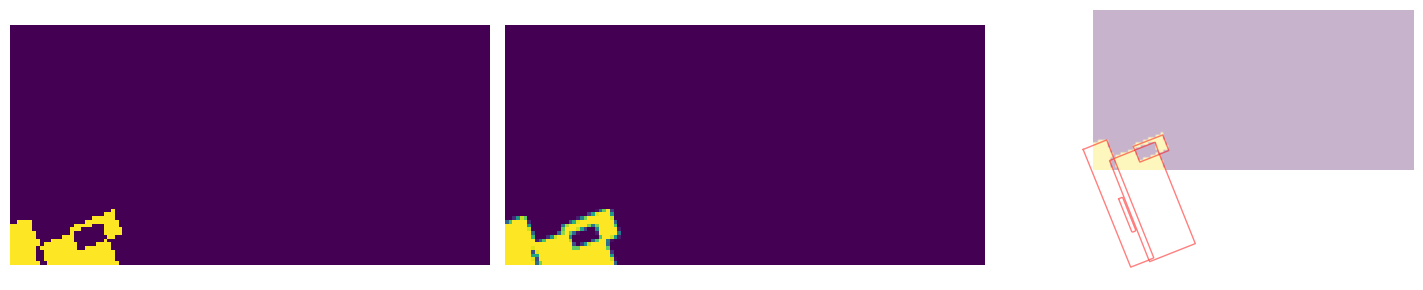

In [3]:
data, label, contours = MakeCoordinatesNMat(rangeAngle=[-45, 45], rangeNum=[1, 4], sizeWH=[128, 64], wRange=[8, 128], hRange=[8, 128], blur=1, scale=5, dilate=1)
plt.figure(figsize=(15, 3))
plt.subplot(1,3,1)
plt.imshow(data, vmin=0, vmax=255)
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(label, vmin=0, vmax=255)
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(data, vmin=0, vmax=255, alpha=0.3)
coordinatesRaw = [np.array(coordinate.tolist() + coordinate[:1].tolist()) for coordinate in contours]
for coordinate in coordinatesRaw:
    plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
pathModel = "model.pickle"
try:
    ckp = pickle.load(open("model.pickle", "rb"))
    modelOptions = ckp["model_options"]
    model = poly2mat(**modelOptions)
    model.load_state_dict(ckp["model_state_dict"])
    print("model loaded")
except:
    print("initial")
    modelOptions = {
        "chanIn" : 1,
        "chanPoly" : 64,
        "chanOut" : 1,
        "scaleList" : [1.0, 0.7, 0.4, 0.1],
        "chanMidList" : [64, 64, 64, 64],
        "repeatAttList"  :[1, 1, 1, 1]
    }
    model = poly2mat(**modelOptions)
device = torch.device("cuda:0")
model.to(device)
lossFuncMSE = torch.nn.MSELoss()
lossFuncIoU = IoULoss(0, 4, 1.0)
learningRate = 0.0005
optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)
numCurrnent = 0

/home/seycho/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


model loaded


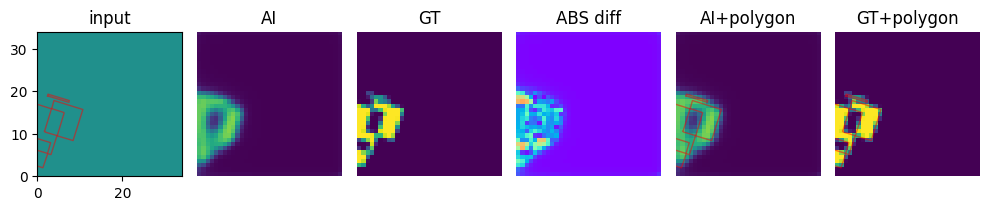

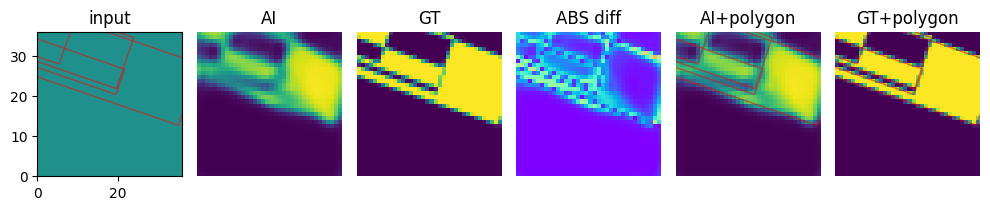

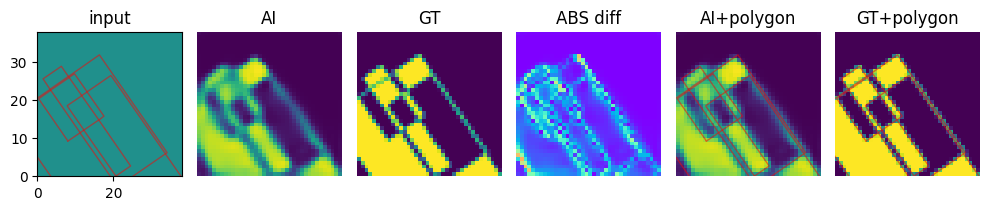

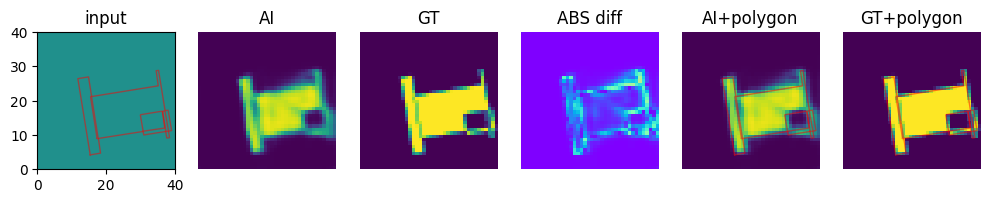

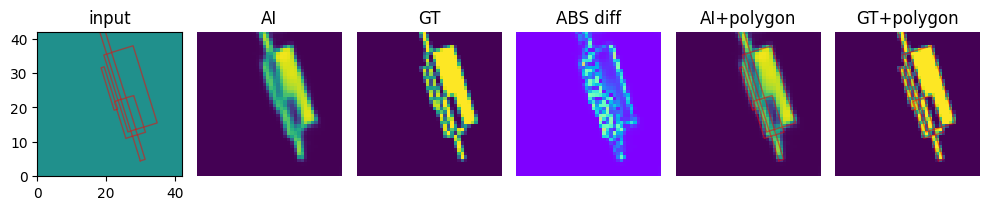

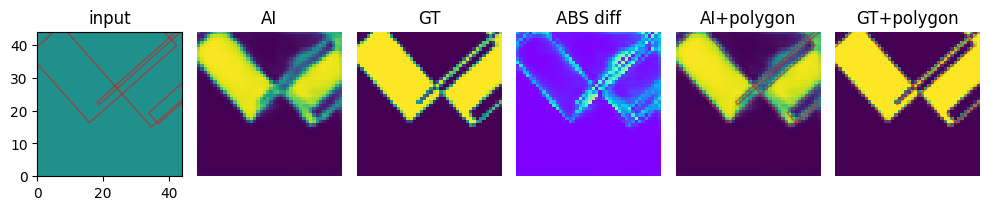

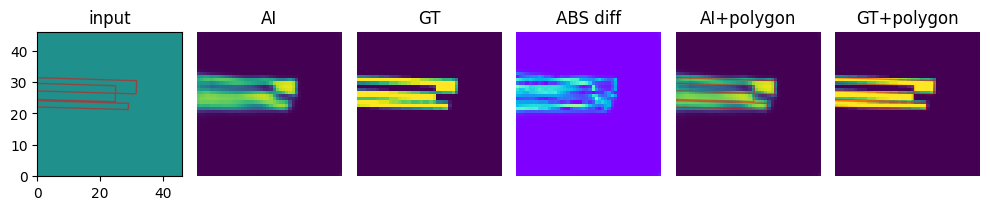

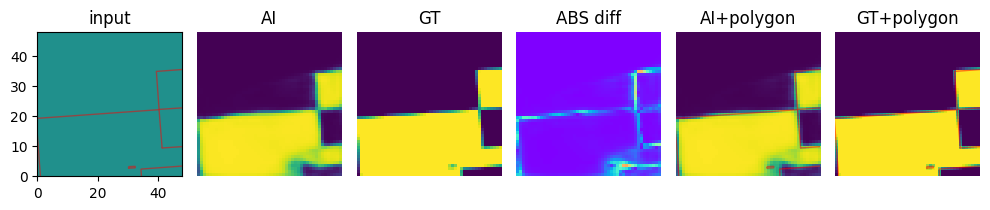

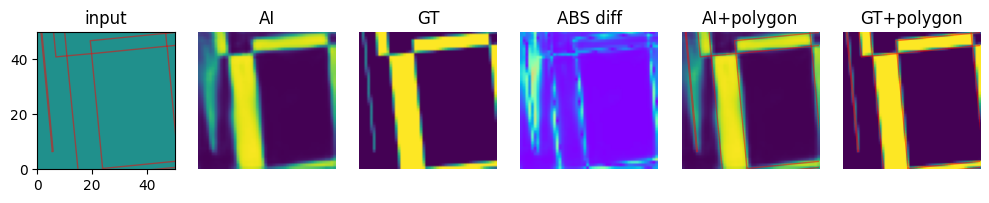

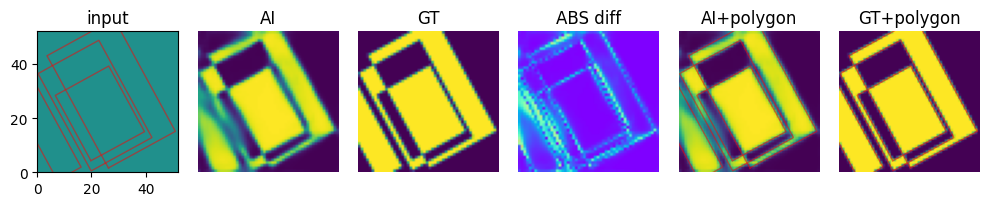

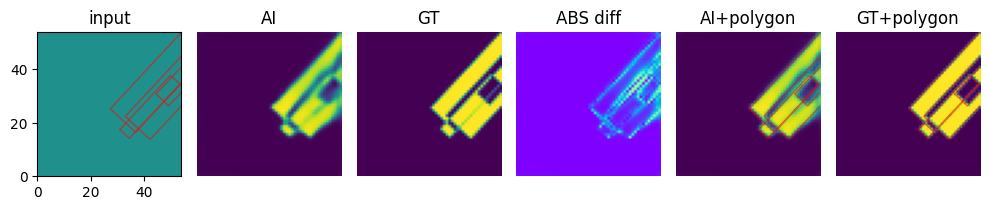

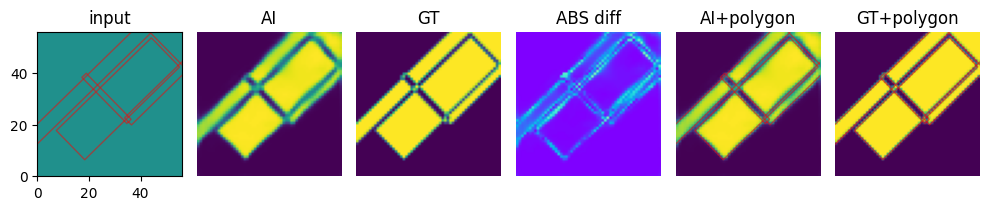

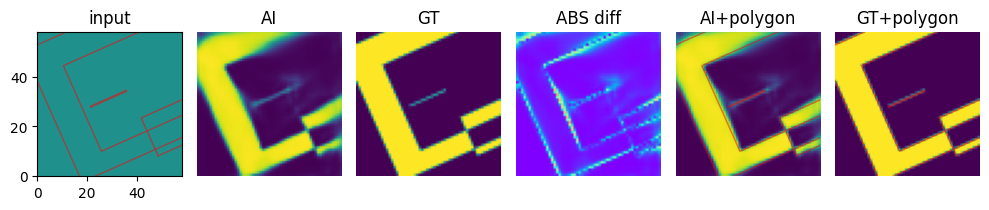

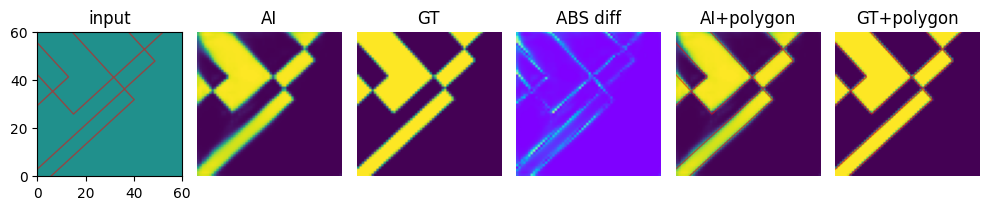

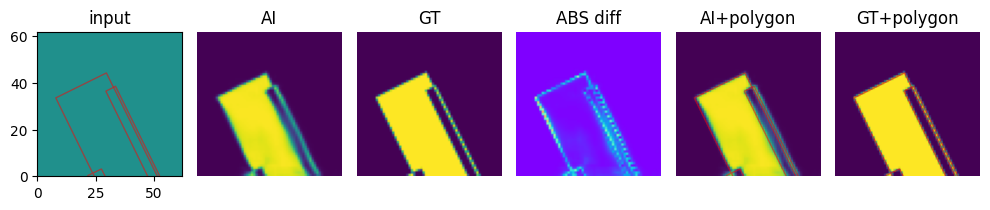

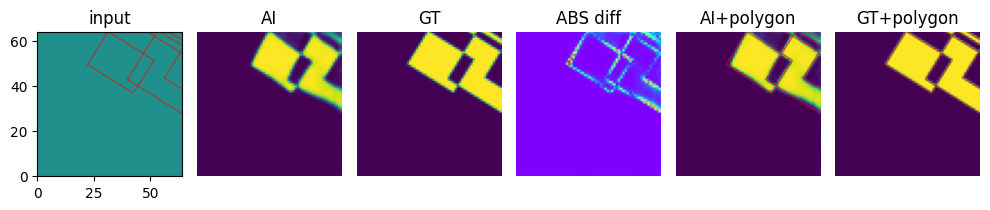

In [4]:
rangeAngle=[-45, 45]
rangeNum=[3, 5]
sizeWH=[32, 32]
wRange=[sizeWH[0]//8, sizeWH[0]+sizeWH[0]//8]
hRange=[sizeWH[1]//8, sizeWH[1]+sizeWH[1]//8]
scale=10
blur=1
dilate=0
batchsize = 64
for c in range(16):
    sizeWH[0] += 2
    sizeWH[1] += 2
    wRange=[sizeWH[0]//8, sizeWH[0]+sizeWH[0]//8]
    hRange=[sizeWH[1]//8, sizeWH[1]+sizeWH[1]//8]
    model.train()
    dataloader = DataLoader(PolyDataset(200000, tfData, tfLabel, rangeAngle=rangeAngle, rangeNum=rangeNum, sizeWH=sizeWH, wRange=wRange, hRange=hRange, scale=scale, blur=blur, dilate=dilate), batch_size=batchsize, shuffle=True, num_workers=12, collate_fn=collate_fn_padd)
    for pack in dataloader:
        datas, labels, coordinates, coordinatePads = pack
        # isPoly = True if np.random.uniform() > 0.5 else False
        isPoly = True
        datas = datas.to(device)
        datas = torch.zeros(*datas.shape, device=device)
        coordinates = coordinates.to(device)
        coordinatePads = coordinatePads.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(datas, coordinates, coordinatePads) if isPoly else model(datas)
        maskEdge = tuple([(labels>0)*(labels<1)])
        loss = lossFuncMSE(outputs, labels)*0.5
        loss += lossFuncMSE(outputs[maskEdge], labels[maskEdge])
        loss += lossFuncIoU(outputs, labels) * 0.3
        loss.backward()
        optimizer.step()
        numCurrnent += len(datas)
        print(c+1, numCurrnent, loss.item(), end="\r")
    model.eval()
    with torch.no_grad():
        data, label, coordinatesRaw = MakeCoordinatesNMat(rangeAngle=rangeAngle, rangeNum=rangeNum, sizeWH=sizeWH, wRange=wRange, hRange=hRange, scale=scale, blur=blur, dilate=dilate)
        datas = tfData(data).unsqueeze(0).to(device)
        datas = torch.zeros(*datas.shape, device=device)
        coordinates = np.concatenate([np.concatenate([coordinate, np.roll(coordinate, shift=-1), np.roll(coordinate, shift=1)], 1) for coordinate in coordinatesRaw], 0)
        coordinates = torch.Tensor(coordinates)/torch.Tensor([*sizeWH]*3)
        coordinates = coordinates.unsqueeze(0).to(device)
        coordinatePads = torch.ones(*coordinates[:,:,0].shape, dtype=torch.bool).to(device)
        labels = tfLabel(label).unsqueeze(0).to(device)
        coordinatesRaw = [np.array(coordinate.tolist() + coordinate[:1].tolist()) for coordinate in coordinatesRaw]
        for isPoly in [True]:
            outputs = model(datas, coordinates, coordinatePads) if isPoly else model(datas)
            plt.figure(figsize=(10, 2))
            plt.subplot(1,6,1)
            plt.title("input")
            plt.imshow(datas[0][0].detach().cpu().numpy(), vmin=-1, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            if isPoly:
                for coordinate in coordinatesRaw:
                    plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            # plt.axis("off")
            plt.subplot(1,6,2)
            plt.title("AI")
            plt.imshow(outputs[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            plt.axis("off")
            plt.subplot(1,6,3)
            plt.title("GT")
            plt.imshow(labels[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            plt.axis("off")
            plt.subplot(1,6,4)
            plt.title("ABS diff")
            plt.imshow(abs(outputs[0][0].detach().cpu().numpy() - labels[0][0].detach().cpu().numpy()), vmin=0, vmax=1, cmap="rainbow", extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            plt.axis("off")
            plt.subplot(1,6,5)
            plt.title("AI+polygon")
            plt.imshow(outputs[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            for coordinate in coordinatesRaw:
                plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            plt.axis("off")
            plt.subplot(1,6,6)
            plt.title("GT+polygon")
            plt.imshow(labels[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
            for coordinate in coordinatesRaw:
                plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
            plt.xlim(0, sizeWH[0])
            plt.ylim(0, sizeWH[1])
            plt.axis("off")
            plt.tight_layout()
            plt.show()

In [ ]:
pickle.dump(
    {
        "model_options" : modelOptions,
        "model_state_dict" : {k : v.cpu() for k, v in model.state_dict().items()}
    },
    open("model.pickle", "wb")
)

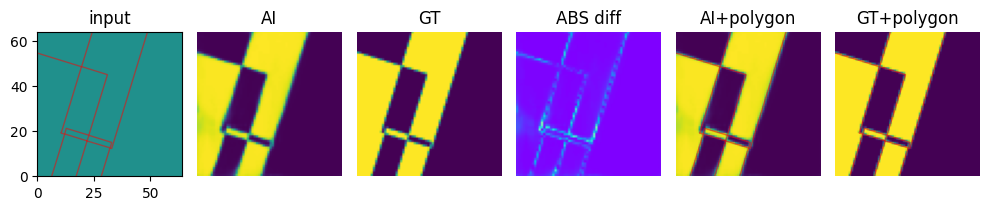

In [8]:
rangeAngle=[-45, 45]
rangeNum=[3, 5]
sizeWH=[64, 64]
wRange=[sizeWH[0]//8, sizeWH[0]+sizeWH[0]//8]
hRange=[sizeWH[1]//8, sizeWH[1]+sizeWH[1]//8]
scale=10
blur=1
dilate=0
model.eval()
with torch.no_grad():
    data, label, coordinatesRaw = MakeCoordinatesNMat(rangeAngle=rangeAngle, rangeNum=rangeNum, sizeWH=sizeWH, wRange=wRange, hRange=hRange, scale=scale, blur=blur, dilate=dilate)
    datas = tfData(data).unsqueeze(0).to(device)
    datas = torch.zeros(*datas.shape, device=device)
    coordinates = np.concatenate([np.concatenate([coordinate, np.roll(coordinate, shift=-1), np.roll(coordinate, shift=1)], 1) for coordinate in coordinatesRaw], 0)
    coordinates = torch.Tensor(coordinates)/torch.Tensor([*sizeWH]*3)
    coordinates = coordinates.unsqueeze(0).to(device)
    coordinatePads = torch.ones(*coordinates[:,:,0].shape, dtype=torch.bool).to(device)
    labels = tfLabel(label).unsqueeze(0).to(device)
    coordinatesRaw = [np.array(coordinate.tolist() + coordinate[:1].tolist()) for coordinate in coordinatesRaw]
    for isPoly in [True]:
        outputs = model(datas, coordinates, coordinatePads) if isPoly else model(datas)
        plt.figure(figsize=(10, 2))
        plt.subplot(1,6,1)
        plt.title("input")
        plt.imshow(datas[0][0].detach().cpu().numpy(), vmin=-1, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        if isPoly:
            for coordinate in coordinatesRaw:
                plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        # plt.axis("off")
        plt.subplot(1,6,2)
        plt.title("AI")
        plt.imshow(outputs[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        plt.axis("off")
        plt.subplot(1,6,3)
        plt.title("GT")
        plt.imshow(labels[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        plt.axis("off")
        plt.subplot(1,6,4)
        plt.title("ABS diff")
        plt.imshow(abs(outputs[0][0].detach().cpu().numpy() - labels[0][0].detach().cpu().numpy()), vmin=0, vmax=1, cmap="rainbow", extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        plt.axis("off")
        plt.subplot(1,6,5)
        plt.title("AI+polygon")
        plt.imshow(outputs[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        for coordinate in coordinatesRaw:
            plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        plt.axis("off")
        plt.subplot(1,6,6)
        plt.title("GT+polygon")
        plt.imshow(labels[0][0].detach().cpu().numpy(), vmin=0, vmax=1, extent=[0, sizeWH[0], 0, sizeWH[1]], origin="lower")
        for coordinate in coordinatesRaw:
            plt.plot(coordinate[:,0], coordinate[:,1], c="red", alpha=0.5, linewidth=1)
        plt.xlim(0, sizeWH[0])
        plt.ylim(0, sizeWH[1])
        plt.axis("off")
        plt.tight_layout()
        plt.show()